In [985]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import os
from random import shuffle

In [986]:

def get_data(dirs):

    max_jerks = []
    max_accs = []
    max_vels = []
    max_heights = []

    jerks = []
    accelerations = []
    velocities = []
    heights = []
    timestamps = []

    for filename in dirs:
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            max_jerk = df['aJerk'].abs().max()
            max_vel = df['aVelocity'].abs().max()
            max_acc = df['aAcc'].abs().max()
            max_height = df['aHeight'].max()

            max_jerks.extend([max_jerk for i in range(len(df))])
            max_accs.extend([max_acc for i in range(len(df))])
            max_vels.extend([max_vel for i in range(len(df))])
            max_heights.extend([max_height for i in range(len(df))])

            jerks.extend(df['aJerk'].abs())
            accelerations.extend(df['aAcc'].abs())
            velocities.extend(df['aVelocity'].abs())
            heights.extend(df['aHeight'].abs())
            timestamps.extend(df['timestamps'])

    data = {
        "max_jerk": max_jerks,
        "max_acc": max_accs,
        "max_vel": max_vels,
        "max_height": max_heights,
        "jerks": jerks,
        "accelerations": accelerations,
        "velocities": velocities,
        "heights": heights,
        "timestamps": timestamps
        }   

    return pd.DataFrame(data)

directory = './lr_data'
dirs = os.listdir(directory)
shuffle(dirs)
test_size = 5
training_df = get_data(dirs[:-test_size])
test_df = get_data(dirs[-test_size:])

In [987]:
degree = 3
predicting = 'velocities'
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
training_features = training_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
poly_model.fit(training_features, training_df[predicting])

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

In [988]:
test_features = test_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
print(test_features)
test_df[f'predicted_{predicting}'] = poly_model.predict(test_features)
print(poly_model.score(test_features, test_df[predicting]))

      timestamps  max_jerk   max_acc   max_vel  max_height
0          0.000  0.505566  0.351010  0.948306    1.910743
1          0.016  0.505566  0.351010  0.948306    1.910743
2          0.047  0.505566  0.351010  0.948306    1.910743
3          0.063  0.505566  0.351010  0.948306    1.910743
4          0.079  0.505566  0.351010  0.948306    1.910743
...          ...       ...       ...       ...         ...
1555       7.235  0.636269  0.705972  3.906577   13.550292
1556       7.250  0.636269  0.705972  3.906577   13.550292
1557       7.266  0.636269  0.705972  3.906577   13.550292
1558       7.281  0.636269  0.705972  3.906577   13.550292
1559       7.297  0.636269  0.705972  3.906577   13.550292

[1560 rows x 5 columns]
0.9218482258214087


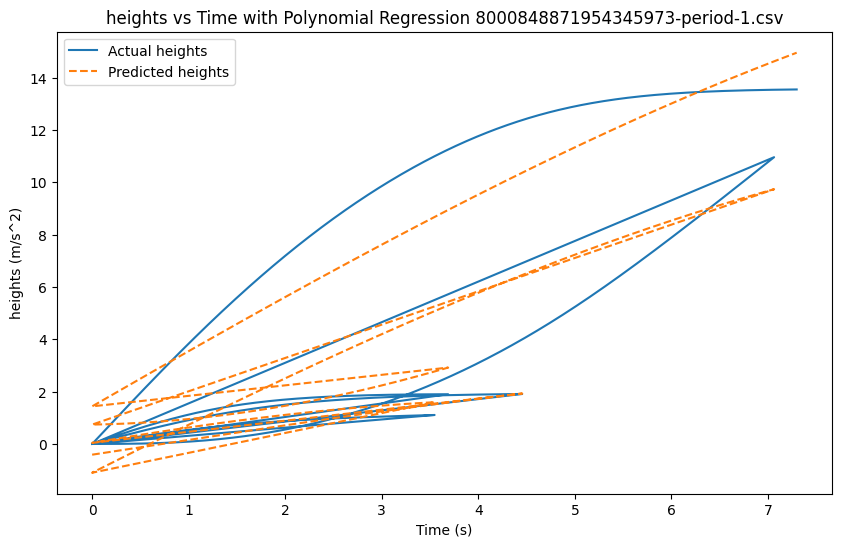

In [989]:
plt.figure(figsize=(10, 6))
plt.plot(test_df['timestamps'], test_df[predicting], label=f'Actual {predicting}')
plt.plot(test_df['timestamps'], test_df[f'predicted_{predicting}'], label=f'Predicted {predicting}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel(f'{predicting} (m/s^2)')
plt.legend()
plt.title(f'{predicting} vs Time with Polynomial Regression {dirs[-1]}')
plt.show()

In [990]:
import pandas as pd
from matplotlib import pyplot as plt
import os
from random import choice

In [991]:

def get_periods(result_file):
    with open("./results/" + result_file, "r") as f:
        df = pd.read_csv(f)

    period_dfs = []
    i = 0
    count = 0
    while i < len(df):

        period = []
        
        # Collect data until aStages is non-zero and there's at least one period element
        while i < len(df) and (df['aStages'].iloc[i] in [1, 3] or not len(period)):
            if df['aStages'].iloc[i] in [1, 3]:
                period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])
            i += 1

        if not len(period) or i >= len(df): continue

        period_df = pd.DataFrame(period, columns=['timestamps', 'aAcc', 'aJerk', 'aVelocity', 'aHeight'])

        period_df["jerks_direction"] = "up" if period_df['aJerk'].iloc[len(period_df) - 1] - period_df['aJerk'].iloc[0] > 0 else "down"
        period_df["accelerations_direction"] = "up" if period_df['aAcc'].iloc[len(period_df) - 1] - period_df['aAcc'].iloc[0] > 0 else "down"
        period_df["velocities_direction"] = "up" if period_df['aVelocity'].iloc[len(period_df) - 1] - period_df['aVelocity'].iloc[0] > 0 else "down"
        period_df["heights_direction"] = "up" if period_df['aHeight'].iloc[len(period_df) - 1] - period_df['aHeight'].iloc[0] > 0 else "down"

        period_df['timestamps'] = period_df['timestamps'] - period_df['timestamps'].iloc[0]

        period_df['aAcc'] = period_df['aAcc'] - period_df['aAcc'].iloc[0]
        period_df['aAcc'] = abs(period_df['aAcc'])


        period_df['aVelocity'] = period_df['aVelocity'] - period_df['aVelocity'].iloc[0]
        period_df['aVelocity'] = abs(period_df['aVelocity'])

        period_df['aHeight'] = period_df['aHeight'] - period_df['aHeight'].iloc[0]
        period_df['aHeight'] = abs(period_df['aHeight'])
        
        period_dfs.append(period_df)

        count += 1
    return period_dfs


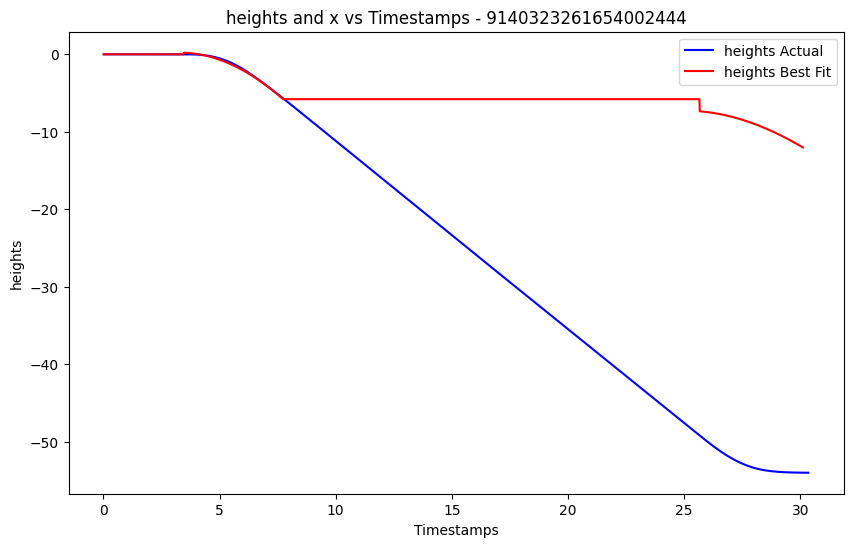

In [992]:

# have predicitng variable
var_map = {
    "heights": "aHeight",
    "accelerations": "aAcc",
    "velocities": "aVelocity",
    "jerks": "aJerk"
}
csv_header = var_map[predicting]

# result_file = "-6502947526604694431"
result_file = choice(os.listdir("./results"))
best_fit = []

df = pd.read_csv(os.path.join("./results/", result_file))
period_dfs = get_periods(result_file)
cumulative_vel = 0
for period_df in period_dfs:
    period_df['max_jerk'] = period_df['aJerk'].abs().max()
    period_df['max_vel'] = period_df['aVelocity'].abs().max()
    period_df['max_acc'] = period_df['aAcc'].abs().max()
    period_df['max_height'] = period_df['aHeight'].abs().max()
    period_df['predicted'] = poly_model.predict(period_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']])
    
    if period_df[f'{predicting}_direction'].iloc[0] == "down":
        period_df['predicted'] *= -1


period_df_index = 0
inner_period_df_index = 0
index = 0
translation_base = 0
while index < len(df) and period_df_index < len(period_dfs):
    if df['aStages'].iloc[index] in [0, 2]:
        if best_fit: best_fit.append(best_fit[-1])
        else: best_fit = [0]
        translation_base = best_fit[-1]
    else:
        best_fit.append(period_dfs[period_df_index]['predicted'].iloc[inner_period_df_index] + translation_base)
        inner_period_df_index += 1
        if inner_period_df_index == len(period_dfs[period_df_index]):
            inner_period_df_index = 0
            period_df_index += 1
    
    index += 1


# Plot df[csv_header] and df['x'] against df['timestamps']
plt.figure(figsize=(10, 6))

plt.plot(df['timestamps'], df[csv_header], label=predicting + " Actual", color='blue')

plt.plot(df['timestamps'][:len(best_fit)], best_fit, label=predicting + " Best Fit", color='red')

# Adding titles and labels
plt.title(f'{predicting} and x vs Timestamps - {result_file}')
plt.xlabel('Timestamps')
plt.ylabel(predicting)

# Display the legend
plt.legend()

# Show the plot
plt.show()